# Week 7 - Milestone One week

# 1. Lesson: no lesson this week.  Milestone One is due!

# 2. Weekly graph question

Below are the graphs from last week's weekly graph question.  Suppose you wanted to cause the viewer to examine the last three months of data first.  How could you use preattentive attributes to do that?  Suggest several possibilities.

In [19]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

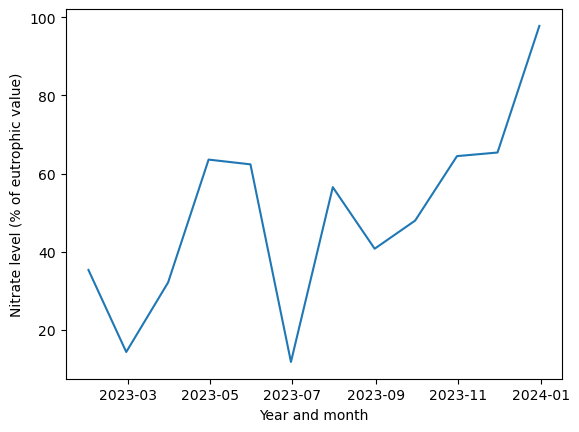

In [20]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

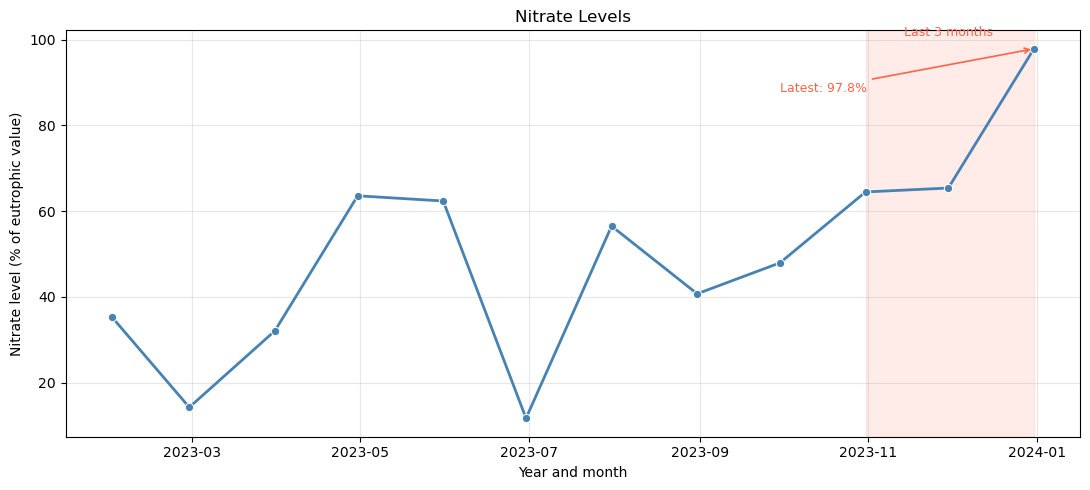

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size=numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')

fig, ax = plt.subplots(figsize=(11, 5))

# Shade last 3 months
ax.axvspan(datearray[-3], datearray[-1], alpha=0.12, color="tomato")

# Base line
sns.lineplot(x=datearray, y=time_series, ax=ax, marker="o", color="steelblue", linewidth=2)

# Label the shaded region
ax.text(datearray[-2], time_series[-3:].max() + 3,
        "Last 3 months", ha="center", color="tomato", fontsize=9)

# Callout on latest value
ax.annotate(f"Latest: {time_series[-1]:.1f}%",
            xy=(datearray[-1], time_series[-1]),
            xytext=(datearray[-4], time_series[-1] - 10),
            fontsize=9, color="tomato",
            arrowprops=dict(arrowstyle="->", color="tomato", lw=1.2))

ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")
ax.set_title("Nitrate Levels")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

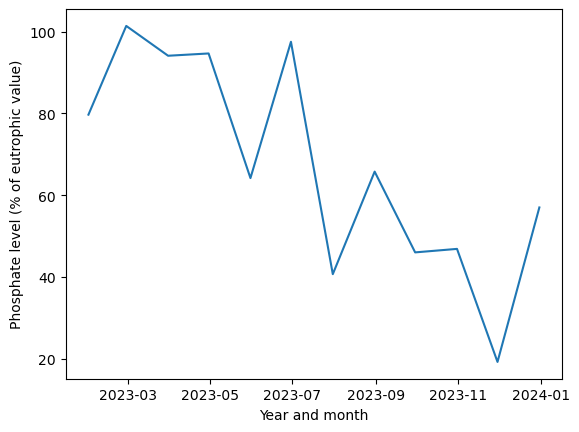

In [22]:
np.random.seed(1)
time_series = 100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

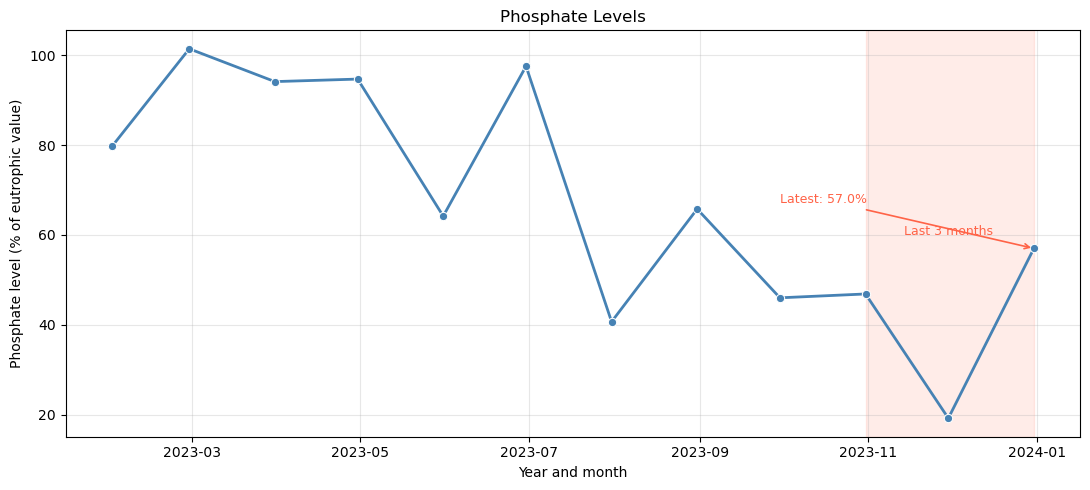

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

numdates = 12
np.random.seed(1)
time_series = 100 * (1 - (np.random.normal(size=numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')

fig, ax = plt.subplots(figsize=(11, 5))

# Shade last 3 months
ax.axvspan(datearray[-3], datearray[-1], alpha=0.12, color="tomato")

# Base line
sns.lineplot(x=datearray, y=time_series, ax=ax, marker="o", color="steelblue", linewidth=2)

# Label the shaded region
ax.text(datearray[-2], time_series[-3:].max() + 3,
        "Last 3 months", ha="center", color="tomato", fontsize=9)

# Callout on latest value
ax.annotate(f"Latest: {time_series[-1]:.1f}%",
            xy=(datearray[-1], time_series[-1]),
            xytext=(datearray[-4], time_series[-1] + 10),
            fontsize=9, color="tomato",
            arrowprops=dict(arrowstyle="->", color="tomato", lw=1.2))

ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")
ax.set_title("Phosphate Levels")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Working on your datasets

This week, you can work on Milestone One rather than having a particular exercise about working on your datasets

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 99-119 of the Storytelling With Data book as best you can. (The first half of chapter four). You do not have to get the exact data values right, just the overall look and feel.

Dataset downloaded to: /Users/rajevasan/.cache/kagglehub/datasets/laotse/credit-risk-dataset/versions/1
Available files: ['credit_risk_dataset.csv']


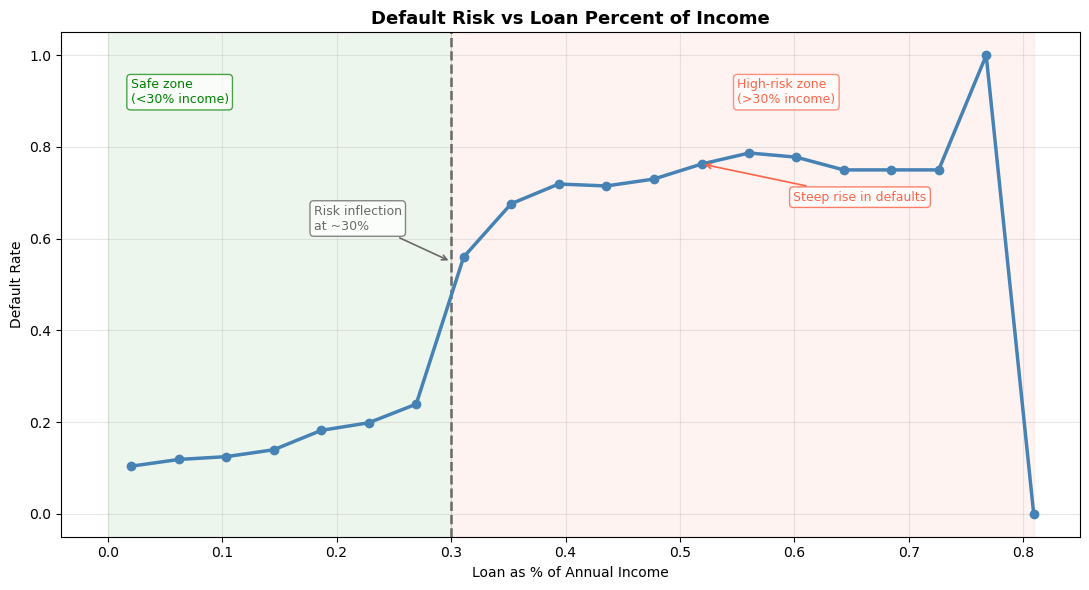

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import kagglehub
import os


path = kagglehub.dataset_download("laotse/credit-risk-dataset")
print("Dataset downloaded to:", path)

files = os.listdir(path)
print("Available files:", files)

csv_file = os.path.join(path, files[0])
credit = pd.read_csv(csv_file)


credit["income_bin"] = pd.cut(credit["loan_percent_income"], bins=20)
line_data = credit.groupby("income_bin")["loan_status"].mean().reset_index()
line_data["bin_mid"] = line_data["income_bin"].apply(lambda x: x.mid).astype(float)
line_data = line_data.dropna(subset=["bin_mid"])

x_max = line_data["bin_mid"].max()
y_max = line_data["loan_status"].max()

fig, ax = plt.subplots(figsize=(11, 6))

# ── Annotation 1: shaded safe zone (green) ───────────────────────────────────
ax.axvspan(0, 0.30, alpha=0.07, color="green")
ax.text(0.02, y_max * 0.95, "Safe zone\n(<30% income)",
        color="green", fontsize=9, va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="green", alpha=0.7))

# ── Annotation 2: shaded high-risk zone (red) ────────────────────────────────
ax.axvspan(0.30, x_max, alpha=0.07, color="tomato")
ax.text(0.55, y_max * 0.95, "High-risk zone\n(>30% income)",
        color="tomato", fontsize=9, va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="tomato", alpha=0.7))

# ── Main line ─────────────────────────────────────────────────────────────────
ax.plot(line_data["bin_mid"], line_data["loan_status"],
        marker="o", linewidth=2.5, color="steelblue", zorder=3)

# ── Annotation 3: threshold line with arrow callout ──────────────────────────
ax.axvline(0.30, linestyle="--", linewidth=1.8, color="dimgray")
ax.annotate("Risk inflection\nat ~30%",
            xy=(0.30, y_max * 0.55),
            xytext=(0.18, y_max * 0.62),
            fontsize=9, color="dimgray",
            arrowprops=dict(arrowstyle="->", color="dimgray", lw=1.2),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="dimgray", alpha=0.8))

# ── Annotation 4: callout on the steepest rise ───────────────────────────────
steep = line_data.loc[line_data["bin_mid"].between(0.30, 0.55), "loan_status"]
if not steep.empty:
    peak_x = line_data.loc[steep.index, "bin_mid"].iloc[-1]
    peak_y = steep.iloc[-1]
    ax.annotate("Steep rise in defaults",
                xy=(peak_x, peak_y),
                xytext=(peak_x + 0.08, peak_y - 0.08),
                fontsize=9, color="tomato",
                arrowprops=dict(arrowstyle="->", color="tomato", lw=1.2),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="tomato", alpha=0.8))

ax.set_title("Default Risk vs Loan Percent of Income", fontsize=13, fontweight="bold")
ax.set_xlabel("Loan as % of Annual Income")
ax.set_ylabel("Default Rate")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The chart shows how the default risk changes as the loan becomes a larger percentage of a borrower’s income. When the loan amount is below about 30% of income, the default rate remains relatively low and stable. This area is labeled the safe zone, suggesting borrowers are generally able to manage repayments when their loan burden is smaller relative to their income.

Around the 30% loan-to-income level, the graph shows a sharp increase in default rates, indicating a risk inflection point. Beyond this threshold, in the high-risk zone, default rates rise significantly and remain high, meaning borrowers whose loans consume a larger portion of their income are much more likely to default. This suggests that loan_percent_income is a strong indicator of credit risk.